# Lab 03: MONAI End to End Workflow

<p align="center">
  <img src="MONAI_LISA_5.png" width="400">
</p>

**MONAI_LISA** (Learning Image Synthesis & Analysis) is a personal medical AI sandbox dedicated to learning and mastering the [MONAI](https://project-monai.github.io/) framework. Built on top of MONAI, this project serves as a practical learning platform and playground for implementing, experimenting with, and benchmarking state-of-the-art 3D medical deep learning techniques. This Lab03 notebook is based on the **"3. End-To-End Workflow with MONAI"** tutorial from the **MONAI Bootcamp 2021**.

### 🔗 Useful Resources
*   **GitHub Repository:** [MONAI Bootcamp 2021 - Day 1](https://github.com/Project-MONAI/MONAIBootcamp2021/tree/main/day1)
*   **Video Tutorial:** [MONAI Bootcamp 2021 Playlist](https://www.youtube.com/watch?v=hCBBDvO3-Ro&list=PLtoSVSQ2XzyCobzE6NvwjNpITsQyPUtfs&index=4)

---
**Adapted by:** Yun-An Huang  
**Date:** June 3rd, 2026


In [1]:
## Initialization: Install MONAI and test the environment

from google.colab import drive # Import Google Colab drive utility
import os # Import os module for interacting with the operating system

# Install PyTorch with CUDA support and MONAI with all its optional dependencies
!pip install --index-url https://download.pytorch.org/whl/cu124 torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0
!pip install "monai[all]" nibabel pydicom ipywidgets==8.1.2


# Clone MONAI tutorials and Bootcamp repositories if they don't already exist
if not os.path.exists("tutorials"):
    !git clone https://github.com/Project-MONAI/tutorials.git
    !git clone https://github.com/Project-MONAI/MONAIBootcamp2021.git

# Ensure MONAI is installed and configured correctly
import monai

# Test environment
import torch

print("GPU Avalable:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU type:", torch.cuda.get_device_name(0))



Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Cloning into 'tutorials'...
remote: Enumerating objects: 8673, done.
remote: Counting objects: 100% (599/599), done.
remote: Compressing objects: 100% (421/421), done.
remote: Total 8673 (delta 430), reused 178 (delta 178), pack-reused 8074 (from 3)
Receiving objects: 100% (8673/8673), 331.19 MiB | 18.47 MiB/s, done.
Resolving deltas: 100% (5137/5137), done.
Cloning into 'MONAIBootcamp2021'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 133 (delta 22), reused 15 (delta 15), pack-reused 105 (from 1)
Receiving objects: 100% (133/133), 86.93 MiB | 16.90 MiB/s, done.
Resolving deltas: 100% (50/50), done.


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


GPU Avalable: True
GPU type: Tesla T4


In [4]:
# Optional:
# if you are using google colab, the server would clean all the data after you disconnect. 
# So, you may like to save the data in your personal space.
# One of the solution is mount Google Drive to persist trained model weights and logs

drive.mount('/content/drive/') # Mount Google Drive to access persistent storage

PROJECT_SANDBOX = "/content/drive/MyDrive/Colab_Workspace/MONAI_LISA" # Define the project sandbox directory within Google Drive

print('Current Dir:')
print(os.listdir(PROJECT_SANDBOX)) # List contents of the project sandbox directory to verify

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/gpu-t4-s-kkb-ass1c2-3984h04sftkll?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_lo

In [5]:
# Examine Nvidia Environment

!nvidia-smi

Thu Jun  4 13:43:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
# avoid the confliction between numpy scipy scikit-learn

!pip install --upgrade numpy scipy scikit-learn

# End-to-end Training with Pytorch and Ignite
---

<img src="monai.png" style="width: 700px;"/>

Welcome to the MONAI bootcamp! This notebook will introduce you to an end-to-end workin in MONAI using both a standard PyTorch loop and using Ignite, followed by a hands-on implementing your own segmentation using everything you've learned so far.

We've covered a lot of material and now it's time to apply the things that we've learned in an end-to-end example.  First, we're going to use the basic PyTorch paradigm for training our model.  We'll then look at how to train using the Ignite workflows to make things even easier!


## End-to-End Training Workflow

To help guide you through training your first model using MONAI, this guide will will cover five key phases:

1. **Setting up our Dataset and exploring the data**
2. **Preparing datasets and transforms**
3. **Define your network and create our PyTorch training loop**
4. **Evaluate your model and understand the results**
5. **Start using Ignite and more about determinism**


Let's get started by importing our dependencies.

In [1]:
import os
import shutil
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import PIL

import torch
import monai

from monai.apps import download_and_extract
from monai.config import print_config
from monai.metrics import ROCAUCMetric
from monai.data import decollate_batch, partition_dataset_classes
from monai.networks.nets import DenseNet121
from monai.transforms import (
    EnsureChannelFirst, # replace old function: addchannel
    EnsureChannelFirstd, # replace old function: addchanneld
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
    ToTensor,
    Activations,
    AsDiscrete,
    EnsureType
)
from monai.utils import set_determinism

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## **1. Setting up our Dataset and exploring the data**

#### Setup data directory

We'll create a temporary directory for all the MONAI data we're going to be using called MONAI_DATA_DIRECTORY.

In [2]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmplbwh2qwr


#### Download the MedNIST dataset
The `MedNIST` dataset was gathered from several sets from [TCIA](https://wiki.cancerimagingarchive.net/display/Public/Data+Usage+Policies+and+Restrictions),
[the RSNA Bone Age Challenge](http://rsnachallenges.cloudapp.net/competitions/4),
and [the NIH Chest X-ray dataset](https://cloud.google.com/healthcare/docs/resources/public-datasets/nih-chest).

The dataset is kindly made available by [Dr. Bradley J. Erickson M.D., Ph.D.](https://www.mayo.edu/research/labs/radiology-informatics/overview) (Department of Radiology, Mayo Clinic)
under the Creative Commons [CC BY-SA 4.0 license](https://creativecommons.org/licenses/by-sa/4.0/). If you use the MedNIST dataset, please acknowledge the source.

We're going to download this dataset below and extract it into our temporary MONAI Data Directory.

In [3]:
resource = "https://www.dropbox.com/s/5wwskxctvcxiuea/MedNIST.tar.gz?dl=1"
md5 = "0bc7306e7427e00ad1c5526a6677552d"

compressed_file = os.path.join(root_dir, "MedNIST.tar.gz")
data_dir = os.path.join(root_dir, "MedNIST")
if not os.path.exists(data_dir):
    download_and_extract(resource, compressed_file, root_dir, md5)

MedNIST.tar.gz: 59.0MB [00:04, 13.7MB/s]                              

2026-06-04 14:20:09,559 - INFO - Downloaded: /tmp/tmplbwh2qwr/MedNIST.tar.gz


2026-06-04 14:20:09,673 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2026-06-04 14:20:09,675 - INFO - Writing into directory: /tmp/tmplbwh2qwr.


#### Set deterministic training for reproducibility
[set_determinism](https://monai.readthedocs.io/en/stable/utils.html#monai.utils.misc.set_determinism) will set the random seeds in both Numpy and PyTorch to ensure reproducibility. We'll see later that we need to go a little bit further to ensure reproducibility in a jupyter notebook

In [4]:
set_determinism(seed=0)

#### Read the image filenames from the dataset folders

When using a dataset, you want to understand the basics of the images, labels, and more.  We'll start off by showing some of those basic statistics for MedNIST.

We'll see that 6 different folders are representing 6 different categories: Hand, AbdomenCT, CXR, ChestCT, BreastMRI, HeadCT.  We'll be using each of these categories as our label names. 

In [5]:
class_names = sorted(x for x in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, x)))
num_class = len(class_names)

image_files = [
    [
        os.path.join(data_dir, class_names[i], x)
        for x in os.listdir(os.path.join(data_dir, class_names[i]))
    ]
    for i in range(num_class)
]

num_each = [len(image_files[i]) for i in range(num_class)]
image_files_list = []
image_class = []

for i in range(num_class):
    image_files_list.extend(image_files[i])
    image_class.extend([i] * num_each[i])
    
num_total = len(image_class)
image_width, image_height = PIL.Image.open(image_files_list[0]).size

print(f"Total image count: {num_total}")
print(f"Image dimensions: {image_width} x {image_height}")
print(f"Label names: {class_names}")
print(f"Label counts: {num_each}")

Total image count: 58954
Image dimensions: 64 x 64
Label names: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Label counts: [10000, 8954, 10000, 10000, 10000, 10000]


#### Randomly pick images from the dataset to visualize and check

We want to understand what the images we're using look like, so we'll start by visualizing a few random images.

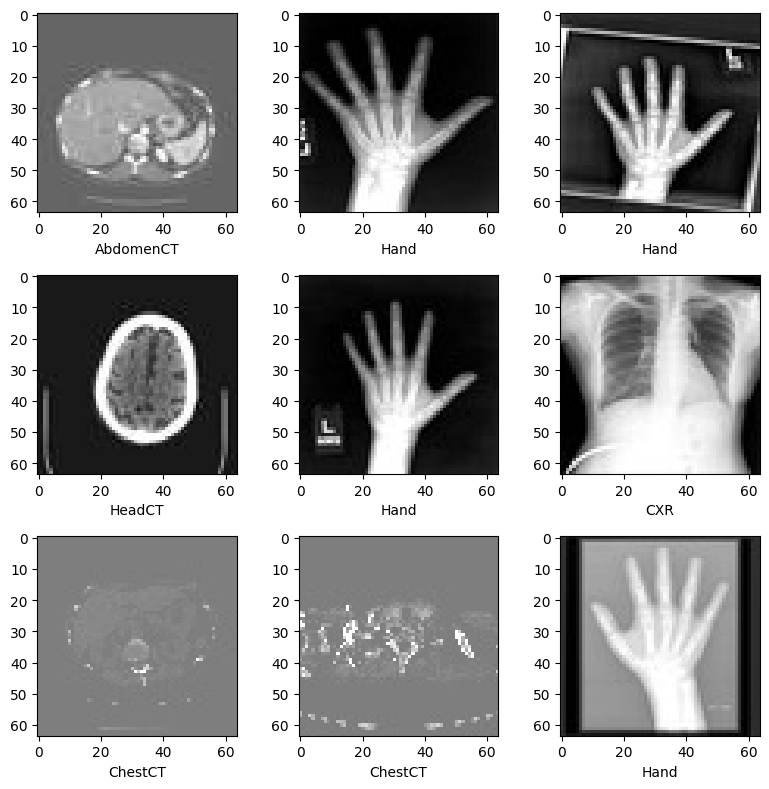

In [6]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(num_total, size=9)):
    im = PIL.Image.open(image_files_list[k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[image_class[k]])
    plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
plt.tight_layout()
plt.show()

## **2. Preparing datasets and transforms**

#### Prepare training, validation, and test data lists

We want to split the data into 3 different sets, one for training, one for validation, and one for testing.  We'll use a ratio of 80/10/10 for those sets.

In [7]:
train_inds, val_inds, test_inds = partition_dataset_classes(np.arange(len(image_files_list)), 
                                                            image_class,(8, 1, 1), shuffle=True)

train_x = [image_files_list[i] for i in train_inds]
train_y = [image_class[i] for i in train_inds]
val_x = [image_files_list[i] for i in val_inds]
val_y = [image_class[i] for i in val_inds]
test_x = [image_files_list[i] for i in test_inds]
test_y = [image_class[i] for i in test_inds]

print(f"Training count: {len(train_x)}, Validation count: {len(val_x)}, Test count: {len(test_x)}")

Training count: 47163, Validation count: 5895, Test count: 5895


#### Define MONAI transforms, Dataset and Dataloader to pre-process data

We'll define our transform using `Compose`.  In this Array of Transforms, we'll load the image, add a channel, scale its intensity, utilize a few random functions and finally create a tensor.

In [8]:
train_transforms = Compose(
    [
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        ScaleIntensity(),
        RandRotate(range_x=15, prob=0.5, keep_size=True),
        RandFlip(spatial_axis=0, prob=0.5),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
        ToTensor(),
    ]
)

val_transforms = Compose([LoadImage(image_only=True), EnsureChannelFirst(), ScaleIntensity(), ToTensor()])

act = Compose([EnsureType(), Activations(softmax=True)]) #EnsureType() make sure the datatype and device are correctly assigned or matched.
to_onehot = Compose([EnsureType(), AsDiscrete(to_onehot=num_class)])

#### Initialise the datasets and loaders for training, validation and test sets
 * Define a simple dataset, that we'll call `MedNISTDataset`, that groups:
   * Images
   * Labels
   * The transforms that are to be run on the images and labels
 * Create three instances of this dataset:
   * One for training
   * One for validation
   * One for testing
   
We'll use a batch size of 512 and employ 10 workers to load the data.

In [9]:
batch_size = 512
num_workers = 2

class MedNISTDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds = MedNISTDataset(train_x, train_y, train_transforms)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)

val_ds = MedNISTDataset(val_x, val_y, val_transforms)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, num_workers=num_workers)

test_ds = MedNISTDataset(test_x, test_y, val_transforms)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, num_workers=num_workers)

## **3. Define your network and create our PyTorch training loop**

#### Define network and optimizer

1. Set `learning_rate` for how much the model is updated per step
1. The fetch a pytorch `device` for the GPU
1. Instantiate a [densenet121](https://monai.readthedocs.io/en/stable/networks.html#monai.networks.nets.DenseNet) model instance and 'send' it to the GPU using `device`
  * This is a standard MONAI implementation; it is capable of 2D and 3D operation but here we are using it in 2D mode
1. We'll make use of the Adam optimizer

In [10]:
learning_rate = 1e-5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net = DenseNet121(spatial_dims=2, in_channels=1, out_channels=num_class).to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), learning_rate)

#### Network training
We are hand-rolling a basic pytorch training loop here:
 * standard pytorch training loop
   * step through each training epoch, running through the training set in batches
   * after each epoch, run a validation pass, evaluating the network
   * if it shows improved performance, save out the model weights
 * later we will revisit training loops in a more Ignite / MONAI fashion

In [11]:
epoch_num = 4
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = list()
metric_values = list()
auc_metric = ROCAUCMetric()

for epoch in range(epoch_num):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{epoch_num}")

    epoch_loss = 0
    step = 1

    steps_per_epoch = len(train_ds) // train_loader.batch_size

    # put the network in train mode; this tells the network and its modules to
    # enable training elements such as normalisation and dropout, where applicable
    net.train()
    for batch_data in train_loader:

        # move the data to the GPU
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)

        # prepare the gradients for this step's back propagation
        optimizer.zero_grad()
        
        # run the network forwards
        outputs = net(inputs)
        
        # run the loss function on the outputs
        loss = loss_function(outputs, labels)
        
        # compute the gradients
        loss.backward()
        
        # tell the optimizer to update the weights according to the gradients
        # and its internal optimisation strategy
        optimizer.step()

        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size + 1}, training_loss: {loss.item():.4f}")
        step += 1

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # after each epoch, run our metrics to evaluate it, and, if they are an improvement,
    # save the model out
    
    # switch off training features of the network for this pass
    net.eval()

    # 'with torch.no_grad()' switches off gradient calculation for the scope of its context
    with torch.no_grad():
        # create lists to which we will concatenate the the validation results
        preds = list()
        labels = list()

        # iterate over each batch of images and run them through the network in evaluation mode
        for val_data in val_loader:
            val_images, val_labels = val_data[0].to(device), val_data[1].to(device)

            # run the network
            val_pred = net(val_images)

            preds.append(val_pred)
            labels.append(val_labels)

        # concatenate the predicted labels with each other and the actual labels with each other
        y_pred = torch.cat(preds)
        y = torch.cat(labels)

        # we are using the area under the receiver operating characteristic (ROC) curve to determine
        # whether this epoch has improved the best performance of the network so far, in which case
        # we save the network in this state
        y_onehot = [to_onehot(i).to(device) for i in decollate_batch(y)]        # to one_hot, the ground truth
        y_pred_act = [act(i).to(device) for i in decollate_batch(y_pred)]       # to softmax, the predicted results  
        
        auc_metric(y_pred_act, y_onehot)
        auc_value = auc_metric.aggregate()
        auc_metric.reset()
        metric_values.append(auc_value)
        
        acc_value = torch.eq(y_pred.argmax(dim=1), y)
        acc_metric = acc_value.sum().item() / len(acc_value)
        
        if auc_value > best_metric:
            best_metric = auc_value
            best_metric_epoch = epoch + 1
            torch.save(net.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
            print("saved new best metric network")
            
        print(
            f"current epoch: {epoch + 1} current AUC: {auc_value:.4f} /"
            f" current accuracy: {acc_metric:.4f} best AUC: {best_metric:.4f} /"
            f" at epoch: {best_metric_epoch}"
        )

print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")

----------
epoch 1/4
1/93, training_loss: 1.7817
2/93, training_loss: 1.7659
3/93, training_loss: 1.7500
4/93, training_loss: 1.7163
5/93, training_loss: 1.6738
6/93, training_loss: 1.6474
7/93, training_loss: 1.6261
8/93, training_loss: 1.6001
9/93, training_loss: 1.5982
10/93, training_loss: 1.5612
11/93, training_loss: 1.5403
12/93, training_loss: 1.5340
13/93, training_loss: 1.5067
14/93, training_loss: 1.4783
15/93, training_loss: 1.4411
16/93, training_loss: 1.4297
17/93, training_loss: 1.4436
18/93, training_loss: 1.3863
19/93, training_loss: 1.3775
20/93, training_loss: 1.3609
21/93, training_loss: 1.3418
22/93, training_loss: 1.3331
23/93, training_loss: 1.3276
24/93, training_loss: 1.3046
25/93, training_loss: 1.2654
26/93, training_loss: 1.2743
27/93, training_loss: 1.2521
28/93, training_loss: 1.2270
29/93, training_loss: 1.2274
30/93, training_loss: 1.1980
31/93, training_loss: 1.1739
32/93, training_loss: 1.1735
33/93, training_loss: 1.1505
34/93, training_loss: 1.1292
35

In [ ]:
# optional: copy the path to colab directory
print("Absolute Path:", os.path.abspath(os.path.join(root_dir, "best_metric_model.pth")))
!cp  /tmp/tmplbwh2qwr/best_metric_model.pth /content/ 


Absolute Path: /tmp/tmplbwh2qwr/best_metric_model.pth


#### Plot the loss and metric

Once we're done training we want to visualize our Loss and Accuracy.

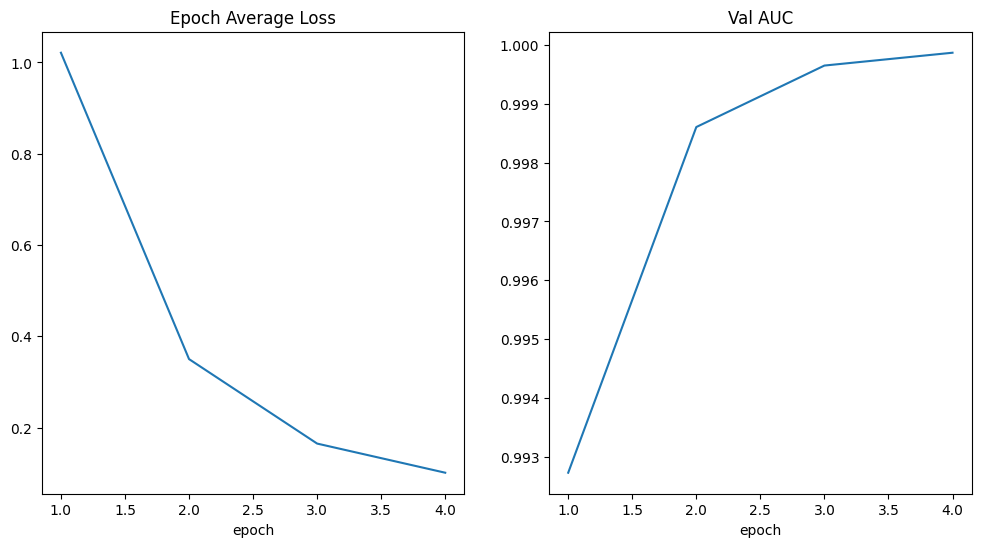

In [12]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val AUC")
x = [(i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

## **4. Evaluate your model and understand the results**

#### Evaluate the model on the test dataset

After training and validation, we now have the best model as determined by the validation dataset.  But now we need to evaluate the model on the test dataset to check whether the final model is robust and not over-fitting.  We'll use these predictions to generate a classification report.

In [13]:
net.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth")))
net.eval()
y_true = list()
y_pred = list()

with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = (
            test_data[0].to(device),
            test_data[1].to(device),
        )
        pred = net(test_images).argmax(dim=1) # select the label
        
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

#### Some light analytics - classification report

We'll utilize scikit-learn's classification report to get the precision, recall, and f1-score for each category.

In [14]:


from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

   AbdomenCT     0.9747    0.9650    0.9698      1000
   BreastMRI     0.9943    0.9821    0.9882       895
         CXR     0.9970    0.9920    0.9945      1000
     ChestCT     0.9911    1.0000    0.9955      1000
        Hand     0.9930    0.9890    0.9910      1000
      HeadCT     0.9677    0.9880    0.9777      1000

    accuracy                         0.9861      5895
   macro avg     0.9863    0.9860    0.9861      5895
weighted avg     0.9862    0.9861    0.9861      5895



#### Some light analytics - confusion matrix

Let's also create a confusion matrix to get a better understanding of the failure cases

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


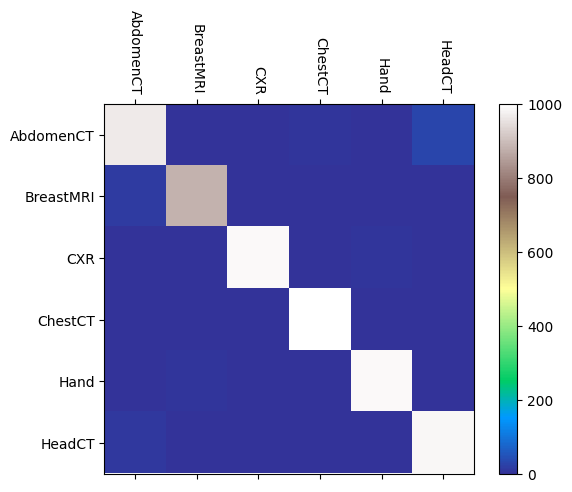

In [15]:
from sklearn.metrics import confusion_matrix
cmat = confusion_matrix(y_true, y_pred)
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion_matrix(y_true, y_pred), cmap="terrain", interpolation='nearest')
fig.colorbar(cax)

ax.set_xticklabels(['']+class_names, rotation=270)
ax.set_yticklabels(['']+class_names)

plt.show()

## **5. Start using Ignite and more about determinism**

#### Let's make some changes
Everything that we have done so far uses MONAI with pytorch in a very vanilla fashion. The initial training / validation loop is written to show you the nuts and bolts of pytorch. Now let's explore starting the move towards [Ignite](https://pytorch.org/ignite/) and features of MONAI designed to work with it.

<img src="workflows.png" style="width: 700px;"/>

In [16]:
# using Ignite engines

from ignite.engine import Events, create_supervised_evaluator, create_supervised_trainer
from ignite.handlers import ModelCheckpoint
from ignite.metrics import Accuracy
from monai.handlers import ROCAUC
import math

step = 1
iter_losses=[]
batch_sizes=[]
epoch_loss_values = []
metric_values = []

# Training

# this trainer takes care of the training loop for us
trainer = create_supervised_trainer(net, optimizer, loss_function, device, False)

# calculate the number of steps per epoch up front
steps_per_epoch = math.ceil(len(train_ds) / train_loader.batch_size)

# create a handler for recording the loss after each input. Improve upon our earlier example
# by also recording the batch size, so we can perform a weighted average for the overall average
# loss
@trainer.on(Events.ITERATION_COMPLETED)
def _end_iter(engine):
    global step
    loss = engine.state.output
    batch_len = len(engine.state.batch[0])
    epoch = engine.state.epoch
    epoch_len = engine.state.max_epochs
    iter_losses.append(loss)
    batch_sizes.append(batch_len)
    print(f'epoch {epoch}/{epoch_len}, step {step}/{steps_per_epoch}, training_loss = {loss:.4f}')    
    step += 1
    
# Validation
def roc_auc_trans(x):
    return [act(i).to(device) for i in decollate_batch(x[0])], [to_onehot(i).to(device) for i in decollate_batch(x[1])]

val_metrics = {
    'accuracy': Accuracy(), 
    'rocauc': ROCAUC(output_transform=roc_auc_trans)
}
evaluator = create_supervised_evaluator(
    net,
    val_metrics,
    device,
    True
)


# validation is run every n training epochs in response to the trainer completing
# an epoch. Here we use the decorator syntax to add a function that runs it to the
# EPOCH_COMPLETED event
@trainer.on(Events.EPOCH_COMPLETED)
def run_validation(engine):
    global step
    evaluator.run(val_loader)

    # the overall average loss must be weighted by batch size
    overall_average_loss = np.average(iter_losses, weights=batch_sizes)
    epoch_loss_values.append(overall_average_loss)

    # clear the contents of iter_losses and batch_sizes for the next epoch
    del iter_losses[:]
    del batch_sizes[:]
    
    # fetch and report the validation metrics
    acc = evaluator.state.metrics['accuracy']
    roc = evaluator.state.metrics['rocauc']
    metric_values.append(roc)
    print(f"evaluation for epoch {engine.state.epoch}, accuracy = {acc:.4f}, rocauc = {roc:.4f}")

    # reset step for the next epoch
    step = 1
    
# create a checkpoint handler to save the network weights based on the area under the ROC curve
# as before
def _score(_):
    return metric_values[-1]

# create a model checkpointer to save the network
checkpoint_handler = ModelCheckpoint(root_dir, filename_prefix='best_metric_model', score_name='',
                                     n_saved=5, require_empty=False, score_function=_score)

# handlers are attached to events in trainers and evaluators
trainer.add_event_handler(event_name=Events.EPOCH_COMPLETED,
                          handler=checkpoint_handler, to_save={'net': net})

# train (and evaluate) the network, Ignite-style!
train_epochs = 4
state = trainer.run(train_loader, train_epochs)

best_rocauc = max(metric_values)
print(f"train completed, best_metric: {best_rocauc:.4f} at epoch: {metric_values.index(best_rocauc)}")

epoch 1/10, step 1/93, training_loss = 0.0804
epoch 1/10, step 2/93, training_loss = 0.0886
epoch 1/10, step 3/93, training_loss = 0.0848
epoch 1/10, step 4/93, training_loss = 0.1045
epoch 1/10, step 5/93, training_loss = 0.0672
epoch 1/10, step 6/93, training_loss = 0.0780
epoch 1/10, step 7/93, training_loss = 0.1037
epoch 1/10, step 8/93, training_loss = 0.0878
epoch 1/10, step 9/93, training_loss = 0.1057
epoch 1/10, step 10/93, training_loss = 0.0894
epoch 1/10, step 11/93, training_loss = 0.0807
epoch 1/10, step 12/93, training_loss = 0.0842
epoch 1/10, step 13/93, training_loss = 0.1070
epoch 1/10, step 14/93, training_loss = 0.0910
epoch 1/10, step 15/93, training_loss = 0.0704
epoch 1/10, step 16/93, training_loss = 0.0830
epoch 1/10, step 17/93, training_loss = 0.0788
epoch 1/10, step 18/93, training_loss = 0.0775
epoch 1/10, step 19/93, training_loss = 0.0842
epoch 1/10, step 20/93, training_loss = 0.0745
epoch 1/10, step 21/93, training_loss = 0.0746
epoch 1/10, step 22/93

This demonstrates using Ignite directly with MONAI. The Engine class used here is also extended by MONAI to provide further facilities related to determinism, providing a default training/evaluating iteration implementation, and dealing with the post-processing of data. These types are not necessary so those new to Ignite or already have their own Ignite-based code can integrate MONAI without having to pick up our types.

Using our MONAI classes we can define a simplified version (with a few features omitted):

In [18]:
# using MONAI engines

from ignite.engine import Events
from ignite.handlers import ModelCheckpoint
from ignite.metrics import Accuracy
from monai.handlers import ROCAUC, ValidationHandler
from monai.engines import SupervisedTrainer, SupervisedEvaluator

train_epochs = 4
iter_losses = []
batch_sizes = []
epoch_loss_values = []
metric_values = []

steps_per_epoch = len(train_ds) // train_loader.batch_size
if len(train_ds) % train_loader.batch_size != 0:
    steps_per_epoch += 1


def roc_auc_trans(x):
    if isinstance(x, list):
        pred = torch.cat([i[0][None, :].to(device) for i in x])
        label = torch.cat([i[1][None, :].to(device) for i in x])
        return pred, label

    return act(x["pred"]), to_onehot(x["label"])


def prepare_batch(batchdata, device, non_blocking):
    img, classes = batchdata
    return img.to(device), classes.to(device)


evaluator = SupervisedEvaluator(
    device=device,
    val_data_loader=val_loader,
    network=net,
    postprocessing=roc_auc_trans,
    key_val_metric={"rocauc": ROCAUC(output_transform=roc_auc_trans)},
    prepare_batch=prepare_batch,
)

trainer = SupervisedTrainer(
    device=device,
    max_epochs=train_epochs,
    train_data_loader=train_loader,
    network=net,
    optimizer=optimizer,
    loss_function=loss_function,
    train_handlers=[ValidationHandler(1, evaluator)],
    prepare_batch=prepare_batch,
)


@trainer.on(Events.ITERATION_COMPLETED)
def _end_iter(engine):
    loss = np.average([o["loss"] for o in engine.state.output])
    batch_len = len(engine.state.batch[0])
    epoch = engine.state.epoch
    epoch_len = engine.state.max_epochs
    step = engine.state.iteration + 1
    iter_losses.append(loss)
    batch_sizes.append(batch_len)

    print(f"epoch {epoch}/{epoch_len}, step {step}/{steps_per_epoch}, training_loss = {loss:.4f}")


@trainer.on(Events.EPOCH_COMPLETED)
def run_validation(engine):
    # the overall average loss must be weighted by batch size
    overall_average_loss = np.average(iter_losses, weights=batch_sizes)
    epoch_loss_values.append(overall_average_loss)

    # clear the contents of iter_losses and batch_sizes for the next epoch
    del iter_losses[:]
    del batch_sizes[:]

    # fetch and report the validation metrics
    roc = evaluator.state.metrics["rocauc"]
    metric_values.append(roc)
    print(f"evaluation for epoch {engine.state.epoch},  rocauc = {roc:.4f}")

    step=1


trainer.run()

epoch 1/4, step 2/93, training_loss = 0.0178
epoch 1/4, step 3/93, training_loss = 0.0191
epoch 1/4, step 4/93, training_loss = 0.0146
epoch 1/4, step 5/93, training_loss = 0.0185
epoch 1/4, step 6/93, training_loss = 0.0056
epoch 1/4, step 7/93, training_loss = 0.0097
epoch 1/4, step 8/93, training_loss = 0.0124
epoch 1/4, step 9/93, training_loss = 0.0066
epoch 1/4, step 10/93, training_loss = 0.0185
epoch 1/4, step 11/93, training_loss = 0.0174
epoch 1/4, step 12/93, training_loss = 0.0157
epoch 1/4, step 13/93, training_loss = 0.0063
epoch 1/4, step 14/93, training_loss = 0.0105
epoch 1/4, step 15/93, training_loss = 0.0150
epoch 1/4, step 16/93, training_loss = 0.0133
epoch 1/4, step 17/93, training_loss = 0.0080
epoch 1/4, step 18/93, training_loss = 0.0084
epoch 1/4, step 19/93, training_loss = 0.0128
epoch 1/4, step 20/93, training_loss = 0.0119
epoch 1/4, step 21/93, training_loss = 0.0079
epoch 1/4, step 22/93, training_loss = 0.0080
epoch 1/4, step 23/93, training_loss = 0.0

## Issues with determinism

MONAI provides `monai.utils.set_determinism` for replicable training
- Easy to not think about, especially in a jupyter / IPython notebook

How many uses of `numpy.random`'s underlying global instance does this notebook have?
- Dataset partitioning
- Image previewing
- MONAI transforms with randomised behaviour can be given / told to create their own internal `numpy.random.RandomState` instances


#### Setting up transforms, revisited

In [22]:
# Even if monai.utils.set_determinism is set globally, rerunning this specific cell 
# multiple times in Jupyter Notebook will still advance the global random state, 
# leading to varying dataset partition sizes across different category classes.
# To guarantee 100% deterministic and reproducible splits on every rerun, 
# we must explicitly pass the local 'seed=rseed' argument directly into this function.

rseed = 12345678

train_transforms = Compose(
    [
        
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        ScaleIntensity(),
        RandRotate(range_x=15, prob=0.5, keep_size=True).set_random_state(rseed),
        RandFlip(spatial_axis=0, prob=0.5).set_random_state(rseed),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5).set_random_state(rseed),
        ToTensor(),
    ]
)

val_transforms = Compose([LoadImage(image_only=True), EnsureChannelFirst(), ScaleIntensity(), ToTensor()])

#### Improving dataset partitioning

Current code results in random numbers of images / labels each time it is run in each category. The solution is to use a deterministic shuffle:

In [23]:
# Even if monai.utils.set_determinism is set globally, rerunning this specific cell 
# multiple times in Jupyter Notebook will still advance the global random state, 
# leading to varying dataset partition sizes across different category classes.
# To guarantee 100% deterministic and reproducible splits on every rerun, 
# we must explicitly pass the local 'seed=rseed' argument directly into this function.

parts = partition_dataset_classes(
    data=np.arange(len(image_files_list)), 
    classes=image_class, 
    ratios=(8, 1, 1), 
    shuffle=True, 
    seed=rseed
)

image_sets = [list(), list(), list()]
label_sets = [list(), list(), list()]

for i, part in enumerate(parts):
    image_sets[i] = [image_files_list[idx] for idx in part]
    label_sets[i] = [image_class[idx] for idx in part]

train_x, val_x, test_x = image_sets
train_y, val_y, test_y = label_sets
print(len(train_x), len(val_x), len(test_x))

47163 5895 5895


## **Summary**

In this notebook, we went through an end-to-end workflow to train the MedNIST dataset using a densenet121 network.  Along the way, you did the following:
- Learned about the MedNIST Data and downloaded it
- Visualized the data to understand the images
- Setup the datasets for use in the model training
- Defined our transforms, datasets, network, and optimizers
- Trained a densenet model and saved the best model as determined by the validation accuracy
- Plotted your training results
- Evaluated your model against the test set
- Ran your final predictions through a classification report to understand more about your final results
- Created a new workflow using Ignite
- Learn more about issues with determinism and how to look out for pitfalls

## **Next Steps**

On day 3 we'll be giving you the opportunity to put all of this together in a single task. We'll have a number of challenges to choose from but you'll need all of your MONAI know how no matter which one you choose. 

You can find more information about everything covered here on our [MONAI Documentation Page](https://monai.readthedocs.io/en/stable/).  

If you're looking for more examples and tutorials, we have a repo dedicated just to that!  You can find it on our [GitHub Organization Page](https://github.com/Project-MONAI/tutorials).  We also have all of our videos from our first ever MONAI Bootcamp available on our [Youtube Channel](https://www.youtube.com/c/ProjectMONAI)